# Final Reproducible Image Preprocessing Pipeline

In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import os
from pathlib import Path
import logging

import cv2
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================
# ============================================================
# PROJECT ROOT DETECTION
# ============================================================

PROJECT_ROOT = Path.cwd()

# If notebook launched from notebooks folder
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"Project Root: {PROJECT_ROOT}")

# ============================================================
# DATA DIRECTORIES
# ============================================================

DATASET_DIR = PROJECT_ROOT/"data"/"raw"

OUTPUT_DIR = PROJECT_ROOT/"data"/"processed"

#DATASET_DIR = Path("data/raw")
#OUTPUT_DIR = Path("data/processed")

FRUITS = ["Banana", "Guava"]

IMAGE_SIZE = (224, 224)
CROP_SIZE = (210, 210)

NUM_SAMPLES = 4

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

np.random.seed(42)

# ============================================================
# LOGGING CONFIGURATION
# ============================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)


Project Root: C:\Users\abiba\Documents\softimpactdemo


In [3]:
# ============================================================
# CENTER CROP FUNCTION
# ============================================================

def crop_center(image, crop_size):

    height, width = image.shape[:2]
    crop_height, crop_width = crop_size

    if crop_height > height or crop_width > width:
        raise ValueError(
            f"Crop size {crop_size} is larger than image size {(height, width)}"
        )

    start_x = width // 2 - crop_width // 2
    start_y = height // 2 - crop_height // 2

    cropped_image = image[
        start_y:start_y + crop_height,
        start_x:start_x + crop_width
    ]

    return cropped_image


# ============================================================
# LOAD AND PREPROCESS IMAGES
# ============================================================

def load_images(
    fruit_directory,
    image_size=IMAGE_SIZE,
    crop_size=CROP_SIZE
):

    images = []
    labels = []

    fruit_directory = Path(fruit_directory)

    if not fruit_directory.exists():
        raise FileNotFoundError(
            f"Dataset directory not found: {fruit_directory}"
        )

    for class_folder in sorted(fruit_directory.iterdir()):

        if not class_folder.is_dir():
            continue

        class_name = class_folder.name

        logging.info(f"Processing class: {class_name}")

        for image_file in sorted(class_folder.iterdir()):

            if not image_file.suffix.lower() in VALID_EXTENSIONS:
                continue

            image = cv2.imread(str(image_file))

            if image is None:
                logging.warning(f"Skipping unreadable image: {image_file.name}")
                continue

            image = cv2.resize(image, image_size)

            image = crop_center(image, crop_size)

            images.append(image)
            labels.append(class_name)

    images = np.array(images)
    labels = np.array(labels)

    logging.info(f"Total images loaded: {len(images)}")

    return images, labels


# ============================================================
# SAVE PROCESSED IMAGES
# ============================================================

def save_images(
    images,
    labels,
    output_directory
):

    output_directory = Path(output_directory)

    output_directory.mkdir(parents=True, exist_ok=True)

    class_counters = {}

    for image, label in zip(images, labels):

        label_directory = output_directory / label
        label_directory.mkdir(parents=True, exist_ok=True)

        if label not in class_counters:
            class_counters[label] = 0

        class_counters[label] += 1

        image_name = f"{label}_{class_counters[label]:04d}.jpg"

        output_path = label_directory / image_name

        cv2.imwrite(str(output_path), image)

    logging.info(f"Images saved to: {output_directory}")


# ============================================================
# DISPLAY SAMPLE IMAGES
# ============================================================

def display_sample_images(
    images,
    labels,
    num_samples=NUM_SAMPLES
):

    unique_labels = sorted(np.unique(labels))

    for label in unique_labels:

        label_images = [
            image for image, lbl in zip(images, labels)
            if lbl == label
        ]

        samples_to_show = min(num_samples, len(label_images))

        fig, axes = plt.subplots(
            1,
            samples_to_show,
            figsize=(15, 4)
        )

        axes = np.atleast_1d(axes)

        fig.suptitle(f"Class: {label}", fontsize=14)

        for i in range(samples_to_show):

            rgb_image = cv2.cvtColor(
                label_images[i],
                cv2.COLOR_BGR2RGB
            )

            axes[i].imshow(rgb_image)
            axes[i].axis("off")

        plt.show()


# ============================================================
# COMPLETE PREPROCESSING PIPELINE
# ============================================================

def process_fruit_dataset(fruit_name):

    logging.info(f"Starting preprocessing for {fruit_name}")

    fruit_path = DATASET_DIR / fruit_name

    output_path = OUTPUT_DIR / fruit_name

    images, labels = load_images(
        fruit_directory=fruit_path,
        image_size=IMAGE_SIZE,
        crop_size=CROP_SIZE
    )

    save_images(
        images=images,
        labels=labels,
        output_directory=output_path
    )

    display_sample_images(
        images=images,
        labels=labels,
        num_samples=NUM_SAMPLES
    )

    logging.info(f"Completed preprocessing for {fruit_name}")


2026-06-12 22:47:39,768 - INFO - Starting preprocessing for Banana
2026-06-12 22:47:39,769 - INFO - Processing class: Class_A
2026-06-12 22:47:49,960 - INFO - Processing class: Class_B
2026-06-12 22:47:55,744 - INFO - Processing class: Defect
2026-06-12 22:48:03,895 - INFO - Total images loaded: 1203
2026-06-12 22:48:05,302 - INFO - Images saved to: C:\Users\abiba\Documents\softimpactdemo\data\processed\Banana


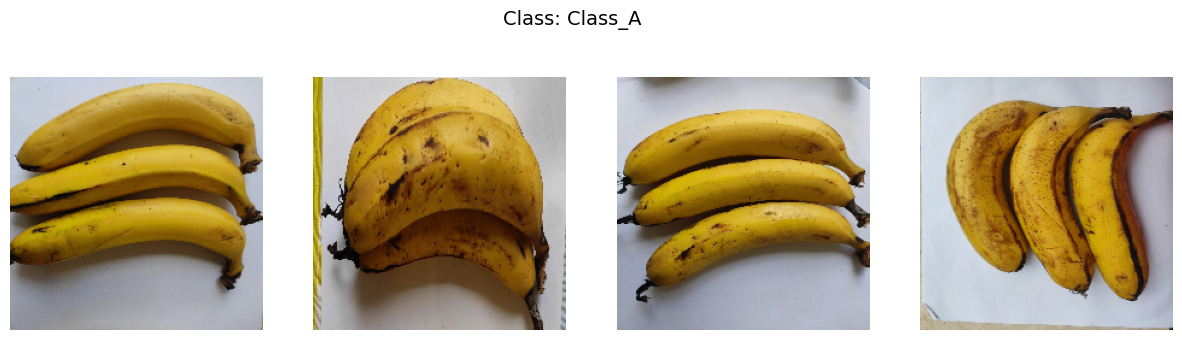

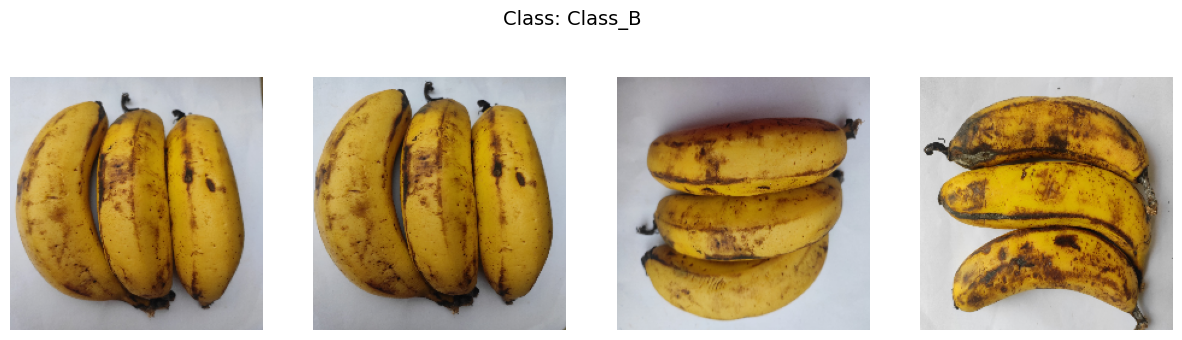

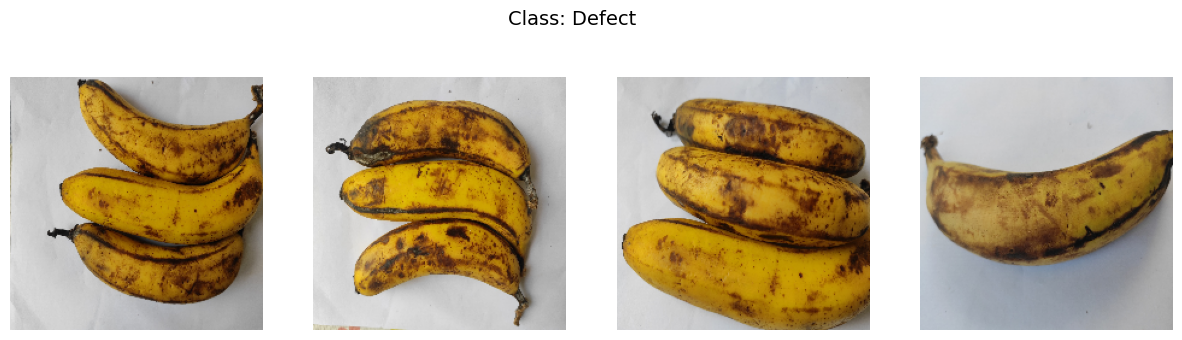

2026-06-12 22:48:06,196 - INFO - Completed preprocessing for Banana
2026-06-12 22:48:06,204 - INFO - Starting preprocessing for Guava
2026-06-12 22:48:06,205 - INFO - Processing class: Class_A
2026-06-12 22:48:09,353 - INFO - Processing class: Class_B
2026-06-12 22:48:12,869 - INFO - Processing class: Defect
2026-06-12 22:48:16,970 - INFO - Total images loaded: 545
2026-06-12 22:48:17,518 - INFO - Images saved to: C:\Users\abiba\Documents\softimpactdemo\data\processed\Guava


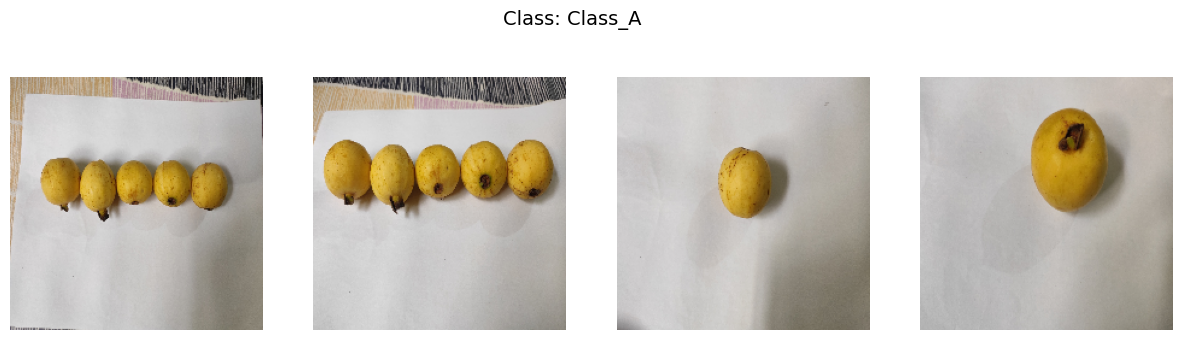

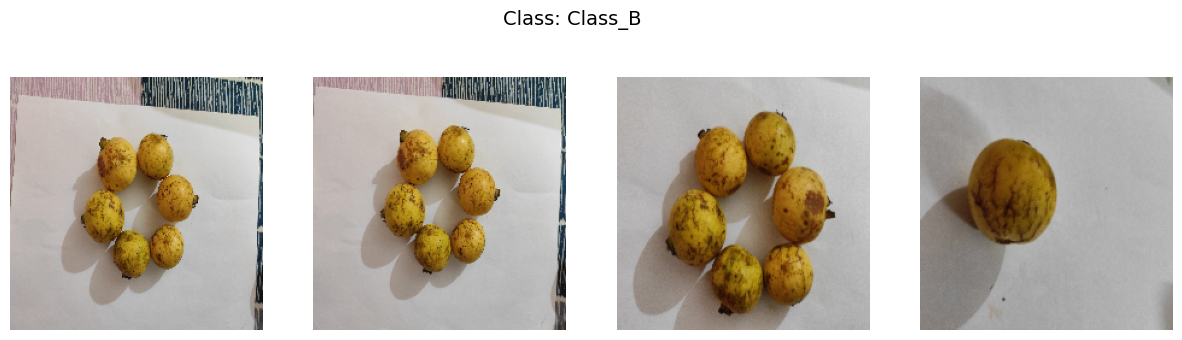

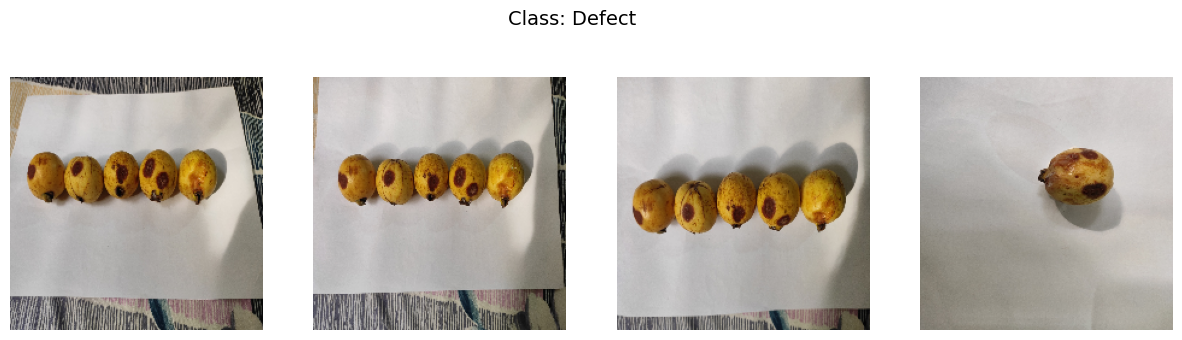

2026-06-12 22:48:18,342 - INFO - Completed preprocessing for Guava
2026-06-12 22:48:18,346 - INFO - All datasets processed successfully.


In [4]:
# ============================================================
# MAIN EXECUTION
# ============================================================

def main():

    for fruit in FRUITS:

        process_fruit_dataset(fruit)

    logging.info("All datasets processed successfully.")


# ============================================================
# RUN PIPELINE
# ============================================================

if __name__ == "__main__":
    main()
